# 06 - Robustness and targeted attack

This notebook looks at how much of Israel's public-transport network survives when stations are taken out of service. We simulate a gradual removal of stations under several *targeted attack* strategies - highest degree, highest weighted degree, highest PageRank, highest betweenness, and articulation points first - and compare each one against a *random failure* baseline averaged over several trials with fixed seeds. The health of the network after each removal step is measured by the size of the largest connected component (LCC): as long as one giant component survives, most riders can still reach most destinations through transfers; once it shatters, the network has effectively split into disconnected regions.

**Research question:** *Is the network fragile to a small number of well-chosen station failures, and which notion of "important station" identifies the most damaging targets?*

**Input**
- The undirected trip-adjacency graph produced in notebook `02_graph_construction` (`outputs/nb/02_graph_construction/...`): a station-level graph where an edge `u - v` means there's a trip serving `v` right after `u`, weighted by the number of trips using that segment. **Required.**
- Optional: the per-station centrality table from the centrality notebook (`stop_metrics.csv`) and the articulation-point list from the descriptive-analysis notebook. If either is missing, this notebook recomputes what it needs on its own, so it can also be run standalone right after notebook 02.

**Output** (all under `outputs/nb/06_robustness_analysis/`)
- `tables/disruption_results.csv` - the full simulation grid: strategy, k removed, LCC size, **and both** normalizations of the LCC's share.
- `tables/ap_dedup_check.csv` - evidence for the deduplication bug fix described below.
- `tables/damage_snapshots.csv` - the LCC's share for each strategy at a few interesting values of k.
- `tables/auc_summary.csv` - the area under each resilience curve (an overall resilience score).
- `figures/resilience_curves_dual.png`, `figures/damage_at_k50_bar.png`, `figures/auc_comparison.png`.

**Two bugs from the previous version of this analysis are fixed here** - both are documented in a separate section before the simulation runs, because they change the conclusions.

## Setting up the environment

The next cell lets the notebook run both on a local copy and on Google Colab: it installs only the packages that are actually missing, locates the repository root (cloning it if we're on Colab), and creates the shared `outputs/nb` folder that every notebook in this series writes to. Nothing here is specific to the robustness analysis - it's the same preamble that appears in all the project notebooks.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## Imports, tunable constants, and the step's output folder

Everything that costs CPU time is controlled by the constants below, so you can shorten the whole notebook's runtime without touching any other cell:

| Constant | Meaning | Cost |
|---|---|---|
| `MAX_REMOVALS = 3000` | how deep the attack goes (about 10% of the roughly 30k stations) | linear |
| `STEPS = 40` | how many points are evaluated along each curve | one connected-components pass per point |
| `EXTRA_KS` | a few small k values added to the grid so the early, interesting part of the curve isn't skipped | 4 extra points |
| `RANDOM_TRIALS = 5` | repeats with fixed seeds averaged for the random baseline | multiplies the baseline cost by 5 |
| `BETWEENNESS_SAMPLES = 300` | number of pivots for approximate betweenness, **used only if** the centrality step isn't available | about 300 BFS passes |

Overall the simulation runs roughly `6 x 44 + 4 x 44 ~ 440` connected-component evaluations on a graph of 30k nodes / 52k edges. On an ordinary laptop that's about 1-3 minutes; it's the only slow part of the notebook. Each removal step uses a *subgraph view* instead of copying the graph, which keeps memory use flat.

This notebook writes only into `outputs/nb/06_robustness_analysis/`.

In [2]:
_ensure('pandas', 'numpy', 'networkx', 'matplotlib')

import pickle, random, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

# ---------------- tunables: all runtime cost lives here ----------------
MAX_REMOVALS = 3000          # deepest attack: ~10% of the network
STEPS = 40                   # evenly spaced points from 0 to MAX_REMOVALS
EXTRA_KS = [10, 25, 50, 100] # small-k anchors so the early curve is resolved
RANDOM_TRIALS = 5            # seeded trials averaged for the random baseline
SEED = 42
BETWEENNESS_SAMPLES = 300    # only used if centrality has to be recomputed here
SNAPSHOT_K = 50              # k used for the 'damage bar chart'

STAGE = OUT / '06_robustness_analysis'
(STAGE / 'tables').mkdir(parents=True, exist_ok=True)
(STAGE / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# numpy 2 renamed trapz -> trapezoid; support both.
_trapz = getattr(np, 'trapezoid', None) or np.trapz

print('stage folder :', STAGE)
print('networkx     :', nx.__version__)
print('pandas       :', pd.__version__)

stage folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\06_robustness_analysis
networkx     : 3.4.2
pandas       : 2.3.3


## Locating the outputs of earlier steps

This notebook consumes the graph built in notebook 02 instead of rebuilding it, because building it requires streaming the 816 MB feed file `stop_times.txt`. The helper functions below search inside `outputs/nb/` for an earlier notebook's step folder and a specific file within it, tolerating small differences in file names. Two loading paths are supported:

1. a `networkx` graph saved as a pickle (`graph_undirected.pkl` or similar) - used directly;
2. otherwise `edges.csv` (plus `nodes.csv` for station attributes) - the undirected graph is rebuilt from it, summing the trip frequency in both travel directions into a single undirected edge weight, exactly as notebook 02 defines it.

If neither exists, we stop with a clear, actionable error instead of quietly analyzing something else. All node IDs are converted to `str` so that IDs coming from a pickle and IDs coming from a CSV can never contradict each other.

In [3]:
def find_stage_dir(*keywords):
    """First sub-folder of OUT whose name contains one of the keywords (case-insensitive)."""
    if not OUT.exists():
        return None
    for kw in keywords:
        for d in sorted(p for p in OUT.iterdir() if p.is_dir()):
            if kw in d.name.lower():
                return d
    return None


def find_file(root, *patterns):
    """First file under `root` matching one of the glob patterns, searched recursively."""
    if root is None or not root.exists():
        return None
    for pat in patterns:
        hits = sorted(root.rglob(pat))
        if hits:
            return hits[0]
    return None


def _pick(columns, options):
    for o in options:
        if o in columns:
            return o
    return None


def to_undirected_sum(D):
    """Collapse a directed graph into an undirected one, summing both directions' weights."""
    U = nx.Graph()
    U.add_nodes_from(D.nodes(data=True))
    for u, v, data in D.edges(data=True):
        w = float(data.get('weight', 1))
        if u == v:
            continue
        if U.has_edge(u, v):
            U[u][v]['weight'] += w
        else:
            U.add_edge(u, v, weight=w)
    return U


def graph_from_csv(edges_csv, nodes_csv=None):
    """Rebuild the undirected, trip-frequency weighted graph from the stage-02 CSV exports."""
    e = pd.read_csv(edges_csv, dtype=str, encoding='utf-8-sig')
    cols = list(e.columns)
    cu = _pick(cols, ['from_stop', 'source', 'from', 'u', 'from_stop_id'])
    cv = _pick(cols, ['to_stop', 'target', 'to', 'v', 'to_stop_id'])
    cw = _pick(cols, ['trip_frequency', 'weight', 'trips', 'count'])
    if cu is None or cv is None:
        cu, cv = cols[0], cols[1]
    us = e[cu].astype(str).tolist()
    vs = e[cv].astype(str).tolist()
    ws = (pd.to_numeric(e[cw], errors='coerce').fillna(1.0).tolist()
          if cw is not None else [1.0] * len(us))

    G = nx.Graph()
    for a, b, w in zip(us, vs, ws):
        if a == b:
            continue
        if G.has_edge(a, b):
            G[a][b]['weight'] += float(w)
        else:
            G.add_edge(a, b, weight=float(w))

    if nodes_csv is not None and Path(nodes_csv).exists():
        n = pd.read_csv(nodes_csv, dtype=str, encoding='utf-8-sig')
        if 'stop_id' in n.columns:
            n = n.set_index(n['stop_id'].astype(str))
            for nid in G.nodes():
                if nid in n.index:
                    row = n.loc[nid]
                    if isinstance(row, pd.DataFrame):
                        row = row.iloc[0]
                    G.nodes[nid].update({k: row.get(k, '') for k in
                                         ['stop_name', 'region', 'metro'] if k in n.columns})
    return G


GRAPH_STAGE = find_stage_dir('graph_construction', 'graph')

graph_pkl = find_file(GRAPH_STAGE, '*undirected*.pkl', 'graph*.pkl', '*.gpickle')
edges_csv = find_file(GRAPH_STAGE, 'edges.csv', '*edges*.csv')

if graph_pkl is not None:
    with open(graph_pkl, 'rb') as f:
        _g = pickle.load(f)
    G = to_undirected_sum(_g) if _g.is_directed() else _g
    GRAPH_SOURCE = graph_pkl
elif edges_csv is not None:
    G = graph_from_csv(edges_csv, find_file(GRAPH_STAGE, 'nodes.csv', '*nodes*.csv'))
    GRAPH_SOURCE = edges_csv
else:
    raise FileNotFoundError(
        'No graph artifact found under ' + str(OUT) + '. Expected a stage folder such as '
        "outputs/nb/02_graph_construction containing graph_undirected.pkl or edges.csv - "
        'run notebook 02_graph_construction first.')

# Normalise node ids to strings and make sure every edge carries a numeric weight.
if any(not isinstance(n, str) for n in G.nodes()):
    G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()})
for _, _, d in G.edges(data=True):
    d['weight'] = float(d.get('weight', 1.0))

N0 = G.number_of_nodes()
components = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
print('graph source        :', GRAPH_SOURCE)
print('nodes / edges       :', format(N0, ','), '/', format(G.number_of_edges(), ','))
print('connected components:', len(components))
print('largest component   :', format(components[0], ','),
      '(' + str(round(100 * components[0] / N0, 2)) + '% of all stations)')

graph source        : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\graph_undirected.pkl
nodes / edges       : 30,463 / 51,772
connected components: 12
largest component   : 30,237 (99.26% of all stations)


## Attack rankings: centrality metrics

A targeted attack needs some ordering over the stations. We use four different notions of importance:

- **degree** - the number of distinct neighboring stations (how many directions you can continue in);
- **weighted degree (strength)** - the same, but weighted by the number of trips on each segment, that is, how much service actually passes through the station. This is a *traffic* notion of importance, and it's always computed here from the graph itself;
- **PageRank** - importance that spreads through the network, so a station is important if important stations feed into it;
- **betweenness** - the fraction of shortest paths passing through the station, that is, how much it acts as a *bridge*. Exact betweenness on 30k nodes is far too slow, so it's approximated from `BETWEENNESS_SAMPLES` random pivots (that's what `nx.betweenness_centrality(..., k=...)` does).

If the centrality notebook has already run, we reuse its `stop_metrics.csv` (so both notebooks tell exactly the same story); otherwise we compute PageRank and sampled betweenness here. Either way the table is remapped onto the graph's own node set, so a station present in the CSV but absent from the graph can't leak into the attack order.

In [4]:
CENT_STAGE = find_stage_dir('centrality')
metrics_csv = find_file(CENT_STAGE, 'stop_metrics.csv', '*metric*.csv')

metrics = None
if metrics_csv is not None:
    m = pd.read_csv(metrics_csv, dtype=str, encoding='utf-8-sig')
    if 'stop_id' in m.columns and {'pagerank', 'betweenness'} <= set(m.columns):
        m['stop_id'] = m['stop_id'].astype(str)
        for c in ['pagerank', 'betweenness']:
            m[c] = pd.to_numeric(m[c], errors='coerce').fillna(0.0)
        m = m[m['stop_id'].isin(G)]
        if len(m) >= 0.5 * N0:
            metrics = m[['stop_id', 'pagerank', 'betweenness']].drop_duplicates('stop_id').copy()
            print('reusing centrality from', metrics_csv, '(' + format(len(metrics), ',') + ' stations)')

if metrics is None:
    print('centrality stage not found - computing PageRank and sampled betweenness here ...')
    t0 = time.time()
    pr = nx.pagerank(G, alpha=0.85, weight='weight')
    print('  pagerank done in', round(time.time() - t0, 1), 's')
    t0 = time.time()
    Gc = G.subgraph(max(nx.connected_components(G), key=len))
    btw = nx.betweenness_centrality(Gc, k=min(BETWEENNESS_SAMPLES, Gc.number_of_nodes()),
                                    seed=SEED, normalized=True)
    print('  sampled betweenness done in', round(time.time() - t0, 1), 's')
    metrics = pd.DataFrame({'stop_id': list(G.nodes())})
    metrics['pagerank'] = metrics['stop_id'].map(pr).fillna(0.0)
    metrics['betweenness'] = metrics['stop_id'].map(btw).fillna(0.0)

# Re-index over the graph's own nodes; degree columns always come from the graph itself.
metrics = (metrics.set_index('stop_id')
                  .reindex(list(G.nodes()))
                  .fillna(0.0)
                  .reset_index()
                  .rename(columns={'index': 'stop_id'}))
metrics['stop_id'] = metrics['stop_id'].astype(str)
metrics['degree'] = metrics['stop_id'].map(dict(G.degree())).astype(float)
metrics['weighted_degree'] = metrics['stop_id'].map(dict(G.degree(weight='weight'))).astype(float)
metrics['stop_name'] = metrics['stop_id'].map({n: G.nodes[n].get('stop_name', '') for n in G.nodes()})

print()
print('metrics table:', metrics.shape)
print(metrics[['degree', 'weighted_degree', 'pagerank', 'betweenness']].describe().round(4).to_string())

centrality stage not found - computing PageRank and sampled betweenness here ...


  pagerank done in 0.2 s


  sampled betweenness done in 41.6 s

metrics table: (30463, 6)
           degree  weighted_degree    pagerank  betweenness
count  30463.0000       30463.0000  30463.0000   30463.0000
mean       3.3990        1003.8915      0.0000       0.0004
std        2.1967        1346.6542      0.0000       0.0020
min        1.0000           1.0000      0.0000       0.0000
25%        2.0000         196.0000      0.0000       0.0000
50%        3.0000         504.0000      0.0000       0.0000
75%        4.0000        1264.0000      0.0000       0.0002
max       62.0000       21396.0000      0.0003       0.1063


## Attack ranking: articulation points

An **articulation point** (cut vertex) is a node whose removal increases the number of connected components. In a transport network these are the single stations holding a whole branch connected to the rest of the country, which makes them the natural candidates for the most damaging targeted attack. `networkx.articulation_points` finds them all in a single DFS pass (`O(V+E)`), which is cheap even on this graph, so we compute them here if the descriptive-analysis notebook hasn't already exported them.

The raw set of articulation points is unordered. To make the strategy well-defined and reproducible, we order the cut vertices by degree, highest to lowest - you'd expect a cut vertex with many connections to disconnect a larger part of the network than a degree-2 cut vertex.

In [5]:
DESC_STAGE = find_stage_dir('descriptive', 'structure')
ap_csv = find_file(DESC_STAGE, 'articulation_points.csv', '*articulation*.csv')

ap_nodes = []
if ap_csv is not None:
    a = pd.read_csv(ap_csv, dtype=str, encoding='utf-8-sig')
    if 'stop_id' in a.columns:
        ap_nodes = [s for s in a['stop_id'].astype(str).tolist() if s in G]
        print('reusing', format(len(ap_nodes), ','), 'articulation points from', ap_csv)

if not ap_nodes:
    t0 = time.time()
    ap_nodes = list(nx.articulation_points(G))
    print('computed', format(len(ap_nodes), ','), 'articulation points in',
          round(time.time() - t0, 1), 's')

deg_map = dict(G.degree())
ap_nodes = sorted(set(ap_nodes), key=lambda n: -deg_map.get(n, 0))
print('articulation points:', format(len(ap_nodes), ','),
      '=', str(round(100 * len(ap_nodes) / N0, 2)) + '% of all stations')
print()
print('top 10 articulation points by degree:')
print(metrics[metrics['stop_id'].isin(ap_nodes[:10])]
      [['stop_id', 'stop_name', 'degree', 'betweenness']]
      .sort_values('degree', ascending=False).to_string(index=False))

reusing 900 articulation points from C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\03_descriptive_analysis\tables\articulation_points.csv
articulation points: 900 = 2.95% of all stations

top 10 articulation points by degree:
stop_id                              stop_name  degree  betweenness
  41133                               מחלף חמד    62.0     0.080752
   9048                 בן גוריון/שערי ירושלים    41.0     0.055286
  10775                   גשר המיתרים/שד' הרצל    37.0     0.010555
  12975                      מחלף לה גווארדייה    34.0     0.024931
  13246                בית ספר הולץ/חיל השריון    31.0     0.026214
  13322                             המסגר/הרכב    27.0     0.001077
   9553                   גשר המיתרים/שד' הרצל    22.0     0.007956
  14355                             מחלף מורשה    20.0     0.025287
  13356                דרך קיבוץ גלויות/כביש 1    20.0     0.008739
  27623 מרכז רפואי סורוקה/אוניברסיטת בן גוריון    20.0     0.

## The two bugs in the previous version of this analysis

The original script (`05_robustness_and_disruption_analysis/scripts/01_robustness.py`) produced the resilience numbers that were quoted before. Two flaws in it are fixed here; both are worth calling out explicitly because they change what the curves mean.

### Bug 1 - the articulation-point curve actually removed fewer stations than the x-axis claims

The articulation-point strategy was built as `ap_list + degree_sorted_list`, and each step removed `set(ordered[:k])`. There are only about 900 articulation points, and each of them **also appears** in the degree-sorted list, so the first `k` entries of the concatenation contain duplicates. Because the removal set is a `set`, for `k` above about 900 the number of distinct stations actually removed is *less* than `k` - the curve was plotted at `x = k` while only `k - (overlap)` stations were deleted. This makes the articulation-point strategy look artificially mild exactly where it should be most aggressive.

**Fix:** deduplicate the concatenated order *while preserving order*, so that position `k` in the list is always the `k`-th distinct station, and assert that exactly `k` distinct nodes are removed at every step. The cell below quantifies the old gap.

### Bug 2 - the LCC's share was normalized by the original station count

The original reported `lcc_share = |LCC| / N_original`. After removing `k` stations, the network can have at most `N_original - k` nodes left, so this metric necessarily drops even if the surviving network is completely intact - it mixes *"we deleted nodes"* with *"the network fell apart"*. For `k = 3000` (about 10% of the network) the raw metric is capped from above at 0.90 no matter what.

**Fix:** report `|LCC| / (N_original - k)`, that is, the share **among the surviving stations** that can still reach each other - a clean fragmentation metric that stays near 1.0 as long as the network is only shrinking. Because the old report quoted the raw version, we compute and plot **both** versions side by side instead of replacing one with the other.

In [6]:
def dedup_keep_order(seq):
    """Remove duplicates but keep first-occurrence order (this is the fix for bug 1)."""
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def order_by(col):
    """Stations sorted by a metric, highest first; ties broken by degree then id for determinism."""
    s = metrics.sort_values([col, 'degree', 'stop_id'], ascending=[False, False, True])
    return s['stop_id'].tolist()


degree_order = order_by('degree')
wdegree_order = order_by('weighted_degree')
pagerank_order = order_by('pagerank')
betweenness_order = order_by('betweenness')

ap_order_buggy = ap_nodes + degree_order            # what the original script did
ap_order = dedup_keep_order(ap_order_buggy)         # fixed: k-th entry is the k-th distinct station

# --- evidence for bug 1: how many distinct stations the old order really removed ---
check_rows = []
for k in [100, 300, 500, 900, 1000, 1500, 2000, 2500, 3000]:
    buggy = len(set(ap_order_buggy[:k]))
    fixed = len(set(ap_order[:k]))
    check_rows.append({'k_on_x_axis': k,
                       'distinct_removed_old': buggy,
                       'distinct_removed_fixed': fixed,
                       'stations_never_removed_old': k - buggy})
ap_check = pd.DataFrame(check_rows)
ap_check.to_csv(STAGE / 'tables' / 'ap_dedup_check.csv', index=False, encoding='utf-8-sig')
print('Bug 1 - articulation-point order, distinct stations actually removed:')
print(ap_check.to_string(index=False))

STRATEGIES = {
    'degree': degree_order,
    'weighted degree': wdegree_order,
    'pagerank': pagerank_order,
    'betweenness': betweenness_order,
    'articulation points': ap_order,
}
for name, order in STRATEGIES.items():
    assert len(order) == len(set(order)), 'duplicate entries in strategy ' + name
    if len(order) < MAX_REMOVALS:
        raise ValueError('strategy ' + name + ' has only ' + str(len(order)) +
                         ' stations, fewer than MAX_REMOVALS=' + str(MAX_REMOVALS))
print()
print('all', len(STRATEGIES), 'attack orders are duplicate-free and long enough.')

Bug 1 - articulation-point order, distinct stations actually removed:
 k_on_x_axis  distinct_removed_old  distinct_removed_fixed  stations_never_removed_old
         100                   100                     100                           0
         300                   300                     300                           0
         500                   500                     500                           0
         900                   900                     900                           0
        1000                   979                    1000                          21
        1500                  1419                    1500                          81
        2000                  1900                    2000                         100
        2500                  2377                    2500                         123
        3000                  2858                    3000                         142

all 5 attack orders are duplicate-free and long enough.


## The simulation engine

`lcc_size` deletes a set of stations and returns the size of the largest connected component that remains. It uses `G.subgraph(survivors)`, which is a read-only *view*: no copy of the 30k-node graph is made, and only the connected-components scan is run, at `O(V+E)` per evaluation.

`simulate` walks the grid of k values for one deterministic strategy and records, for each point, the LCC size together with **both** normalizations (bug 2). It asserts that exactly `k` distinct stations were removed at each step (bug 1).

`simulate_random` is the baseline: for each of the `RANDOM_TRIALS` trials with fixed seeds it draws one random permutation of the stations and removes the first `k` entries of it. Using a permutation instead of an independent sample for each `k` makes each trial a consistent gradual-failure sequence (the removals are nested, as in a real cascading failure), and then the trials are averaged. This is the baseline every targeted strategy must beat to count as "targeted".

In [7]:
ALL_NODES = list(G.nodes())
NODE_SET = set(ALL_NODES)


def k_grid():
    """Evenly spaced removal counts plus a few small-k anchors, sorted and unique."""
    ks = {int(round(x)) for x in np.linspace(0, MAX_REMOVALS, STEPS)}
    ks.update(k for k in EXTRA_KS if k <= MAX_REMOVALS)
    return sorted(ks)


def lcc_size(removed):
    """Size of the largest connected component after deleting `removed` (a set of node ids)."""
    survivors = NODE_SET.difference(removed)
    if not survivors:
        return 0
    return max((len(c) for c in nx.connected_components(G.subgraph(survivors))), default=0)


def _row(strategy, k, size):
    surviving = N0 - k
    return {
        'strategy': strategy,
        'removed': k,
        'surviving_nodes': surviving,
        'lcc_size': size,
        # bug 2: the original (misleading) normalization, kept for comparability with the old report
        'lcc_share_original': round(size / N0, 5),
        # bug 2 fixed: fragmentation among the stations that are still there
        'lcc_share_surviving': round(size / surviving, 5) if surviving > 0 else 0.0,
    }


def simulate(strategy, order, verbose=True):
    order = [n for n in order if n in NODE_SET]
    rows = []
    t0 = time.time()
    for k in k_grid():
        removed = set(order[:k])
        assert len(removed) == k, 'strategy ' + strategy + ' removed ' + str(len(removed)) + ' != k=' + str(k)
        rows.append(_row(strategy, k, lcc_size(removed)))
    if verbose:
        print('  ' + strategy.ljust(22), 'done in', round(time.time() - t0, 1), 's',
              '| LCC share (surviving) at k=' + str(MAX_REMOVALS) + ':',
              rows[-1]['lcc_share_surviving'])
    return pd.DataFrame(rows)


def simulate_random(trials=RANDOM_TRIALS, seed=SEED, verbose=True):
    ks = k_grid()
    sizes = {k: [] for k in ks}
    t0 = time.time()
    for t in range(trials):
        rng = random.Random(seed + t)
        perm = list(ALL_NODES)
        rng.shuffle(perm)
        for k in ks:
            sizes[k].append(lcc_size(set(perm[:k])))
    rows = [_row('random (baseline)', k, float(np.mean(sizes[k]))) for k in ks]
    if verbose:
        print('  ' + 'random (baseline)'.ljust(22), 'done in', round(time.time() - t0, 1), 's',
              '|', trials, 'seeded trials averaged')
    return pd.DataFrame(rows)


print('k-grid (' + str(len(k_grid())) + ' points):', k_grid()[:12], '...', k_grid()[-3:])

k-grid (44 points): [0, 10, 25, 50, 77, 100, 154, 231, 308, 385, 462, 538] ... [2846, 2923, 3000]


## Running the simulation

This is the computationally expensive cell (about 1-3 minutes; you can lower `STEPS`, `MAX_REMOVALS`, or `RANDOM_TRIALS` to shorten it). It runs the five targeted strategies and the random baseline on the same grid of k values and concatenates everything into one tidy dataframe, which is then written to `tables/disruption_results.csv` with both normalizations shown side by side.

In [8]:
print('simulating attacks (', len(k_grid()), 'removal levels per strategy )')
t_all = time.time()

frames = [simulate(name, order) for name, order in STRATEGIES.items()]
frames.append(simulate_random())

results = pd.concat(frames, ignore_index=True)
results.to_csv(STAGE / 'tables' / 'disruption_results.csv', index=False, encoding='utf-8-sig')

print()
print('total simulation time:', round(time.time() - t_all, 1), 's')
print('saved', STAGE / 'tables' / 'disruption_results.csv', '(' + str(len(results)), 'rows )')
print()
print(results.head(8).to_string(index=False))

simulating attacks ( 44 removal levels per strategy )


  degree                 done in 3.5 s | LCC share (surviving) at k=3000: 0.36019


  weighted degree        done in 3.2 s | LCC share (surviving) at k=3000: 0.9125


  pagerank               done in 3.1 s | LCC share (surviving) at k=3000: 0.79383


  betweenness            done in 3.1 s | LCC share (surviving) at k=3000: 0.34031


  articulation points    done in 3.1 s | LCC share (surviving) at k=3000: 0.4103


  random (baseline)      done in 16.6 s | 5 seeded trials averaged

total simulation time: 32.6 s
saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\06_robustness_analysis\tables\disruption_results.csv (264 rows )

strategy  removed  surviving_nodes  lcc_size  lcc_share_original  lcc_share_surviving
  degree        0            30463   30237.0             0.99258              0.99258
  degree       10            30453   30192.0             0.99110              0.99143
  degree       25            30438   30167.0             0.99028              0.99110
  degree       50            30413   30130.0             0.98907              0.99069
  degree       77            30386   30082.0             0.98749              0.99000
  degree      100            30363   30032.0             0.98585              0.98910
  degree      154            30309   29944.0             0.98296              0.98796
  degree      231            30232   29530.0             0.9693

## Resilience curves under both normalizations

The figure below shows the same simulation twice.

- **Left - `|LCC| / N_original`**: the metric used in the previous report. The dashed gray line is the *ceiling* `(N_original - k) / N_original`: no curve can rise above it, because the removed stations no longer exist. Any distance between a curve and that ceiling is real fragmentation; the rest of the drop is just accounting.
- **Right - `|LCC| / (N_original - k)`**: the corrected metric. It starts around 0.99 (the graph isn't fully connected to begin with - there are a few small components) and drops only when the surviving network actually breaks into pieces. A curve that stays flat here means the attack removed stations but did **not** shatter the network.

The gap between a targeted curve and the random baseline is the actual answer to the research question: it measures how much worse a smart attacker is than bad luck.

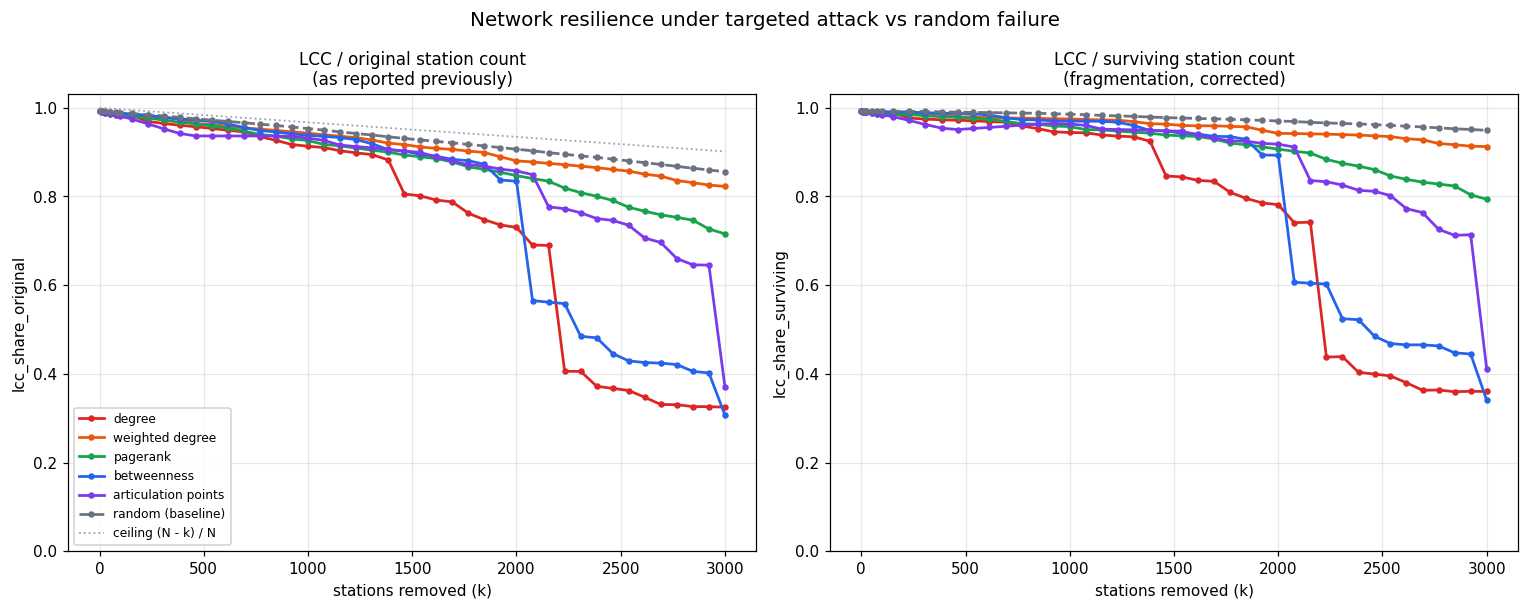

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\06_robustness_analysis\figures\resilience_curves_dual.png


In [9]:
COLORS = {
    'degree': '#dc2626',
    'weighted degree': '#ea580c',
    'pagerank': '#16a34a',
    'betweenness': '#2563eb',
    'articulation points': '#7c3aed',
    'random (baseline)': '#6b7280',
}
STRATEGY_ORDER = list(COLORS.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharex=True)
panels = [
    ('lcc_share_original', 'LCC / original station count\n(as reported previously)'),
    ('lcc_share_surviving', 'LCC / surviving station count\n(fragmentation, corrected)'),
]

ks = np.array(k_grid(), dtype=float)
for ax, (col, title) in zip(axes, panels):
    for strat in STRATEGY_ORDER:
        g = results[results['strategy'] == strat].sort_values('removed')
        if g.empty:
            continue
        ax.plot(g['removed'], g[col], marker='o', markersize=3.2, linewidth=1.8,
                label=strat, color=COLORS[strat],
                linestyle='--' if strat == 'random (baseline)' else '-')
    if col == 'lcc_share_original':
        ax.plot(ks, (N0 - ks) / N0, color='#9ca3af', linewidth=1.2, linestyle=':',
                label='ceiling (N - k) / N')
    ax.set_xlabel('stations removed (k)')
    ax.set_ylabel(col)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.03)

axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)
fig.suptitle('Network resilience under targeted attack vs random failure', fontsize=13)
fig.tight_layout()
fig.savefig(STAGE / 'figures' / 'resilience_curves_dual.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved', STAGE / 'figures' / 'resilience_curves_dual.png')

## Damage snapshots at specific attack sizes

Curves are good for understanding shape, but the report needs numbers. The next cell extracts the state of the network at three representative attack sizes - a very small attack (`k = 50`, about 0.16% of the stations), a medium attack (`k = 500`), and the deepest one simulated (`k = MAX_REMOVALS`) - for each strategy under both normalizations, and draws a grouped bar chart for `k = SNAPSHOT_K`. Because the grid of k values now contains explicit anchors at small k, the `k = 50` row is a genuine simulated point and not the nearest available one (the previous version labeled a chart as "k ~ 50" while actually plotting `k = 77`).

--- k = 50 (0.16% of stations removed) ---
           strategy  lcc_size  lcc_share_original  lcc_share_surviving
articulation points   30037.0             0.98602              0.98764
           pagerank   30055.0             0.98661              0.98823
             degree   30130.0             0.98907              0.99069
    weighted degree   30140.0             0.98940              0.99102
        betweenness   30150.0             0.98973              0.99135
  random (baseline)   30180.2             0.99072              0.99235

--- k = 3000 (9.85% of stations removed) ---
           strategy  lcc_size  lcc_share_original  lcc_share_surviving
        betweenness    9346.0             0.30680              0.34031
             degree    9892.0             0.32472              0.36019
articulation points   11268.0             0.36989              0.41030
           pagerank   21801.0             0.71566              0.79383
    weighted degree   25060.0             0.82264          

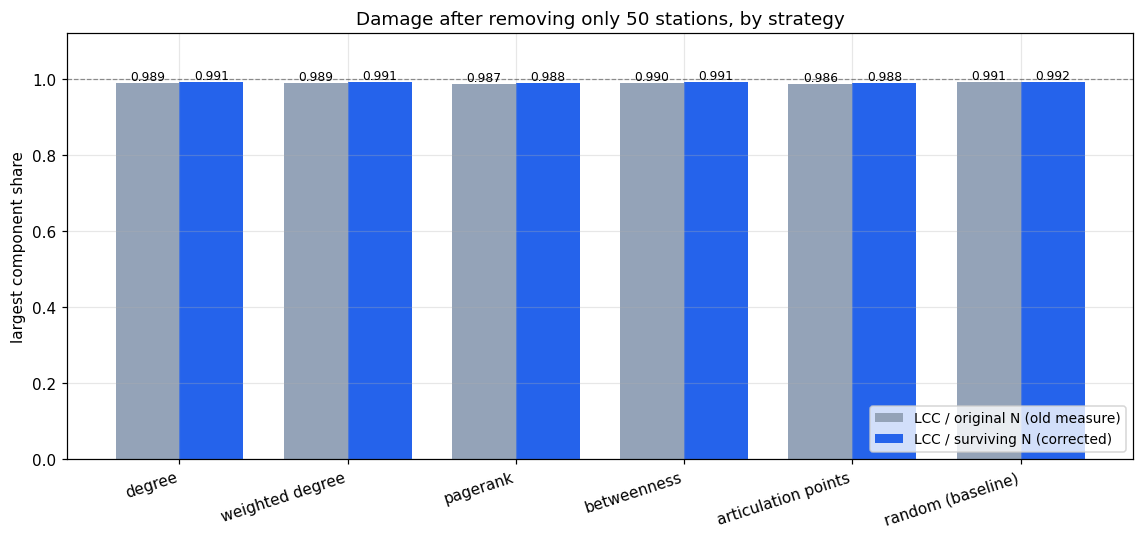

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\06_robustness_analysis\figures\damage_at_k50_bar.png


In [10]:
snapshot_ks = [k for k in [SNAPSHOT_K, 500, MAX_REMOVALS] if k in set(k_grid())]
snapshots = (results[results['removed'].isin(snapshot_ks)]
             .sort_values(['removed', 'lcc_share_surviving'])
             .reset_index(drop=True))
snapshots.to_csv(STAGE / 'tables' / 'damage_snapshots.csv', index=False, encoding='utf-8-sig')
for k in snapshot_ks:
    print('--- k =', k, '(' + str(round(100 * k / N0, 2)) + '% of stations removed) ---')
    print(snapshots[snapshots['removed'] == k]
          [['strategy', 'lcc_size', 'lcc_share_original', 'lcc_share_surviving']]
          .to_string(index=False))
    print()

snap = (snapshots[snapshots['removed'] == SNAPSHOT_K]
        .set_index('strategy')
        .reindex([s for s in STRATEGY_ORDER])
        .dropna(subset=['lcc_size']))
x = np.arange(len(snap))
width = 0.38

fig, ax = plt.subplots(figsize=(10.5, 5))
b1 = ax.bar(x - width / 2, snap['lcc_share_original'], width,
            color='#94a3b8', label='LCC / original N (old measure)')
b2 = ax.bar(x + width / 2, snap['lcc_share_surviving'], width,
            color='#2563eb', label='LCC / surviving N (corrected)')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                format(bar.get_height(), '.3f'), ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(snap.index, rotation=18, ha='right')
ax.set_ylabel('largest component share')
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_title('Damage after removing only ' + str(SNAPSHOT_K) + ' stations, by strategy')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(STAGE / 'figures' / 'damage_at_k50_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved', STAGE / 'figures' / 'damage_at_k50_bar.png')

## One number per strategy: the area under the resilience curve

To rank the strategies overall we integrate each curve with the trapezoid rule and divide by `MAX_REMOVALS`. The result is the *average* share of the largest connected component over the whole attack, on a 0-1 scale: **a lower value means the strategy did more damage**, that is, it's a better attack (and identifies the more critical stations). We report the AUC for both normalizations; the ranking should be identical, since the two metrics differ by a factor that depends only on `k` and not on the strategy.

Average largest-component share over the attack (lower = more damaging attack):
           strategy  auc_original  auc_surviving  rank_most_damaging
             degree        0.7340         0.7655                   1
        betweenness        0.7799         0.8145                   2
articulation points        0.8546         0.8964                   3
           pagerank        0.8778         0.9216                   4
    weighted degree        0.9122         0.9587                   5
  random (baseline)        0.9283         0.9760                   6


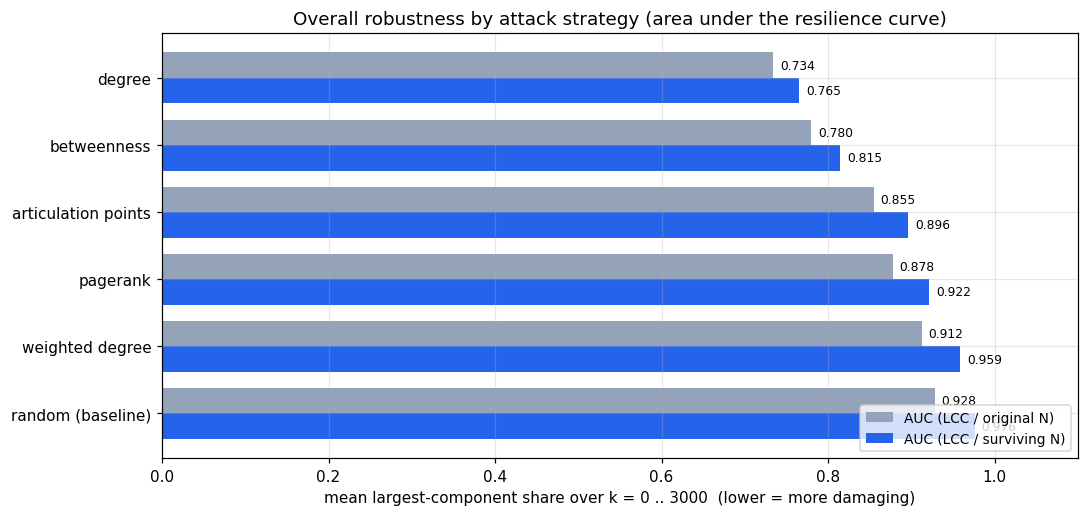

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\06_robustness_analysis\figures\auc_comparison.png


In [11]:
auc_rows = []
for strat in STRATEGY_ORDER:
    g = results[results['strategy'] == strat].sort_values('removed')
    if g.empty:
        continue
    auc_rows.append({
        'strategy': strat,
        'auc_original': round(float(_trapz(g['lcc_share_original'], g['removed'])) / MAX_REMOVALS, 4),
        'auc_surviving': round(float(_trapz(g['lcc_share_surviving'], g['removed'])) / MAX_REMOVALS, 4),
    })
auc = pd.DataFrame(auc_rows).sort_values('auc_surviving').reset_index(drop=True)
auc['rank_most_damaging'] = np.arange(1, len(auc) + 1)
auc.to_csv(STAGE / 'tables' / 'auc_summary.csv', index=False, encoding='utf-8-sig')
print('Average largest-component share over the attack (lower = more damaging attack):')
print(auc.to_string(index=False))

y = np.arange(len(auc))
height = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(y - height / 2, auc['auc_original'], height, color='#94a3b8', label='AUC (LCC / original N)')
ax.barh(y + height / 2, auc['auc_surviving'], height, color='#2563eb', label='AUC (LCC / surviving N)')
for yi, (a, b) in enumerate(zip(auc['auc_original'], auc['auc_surviving'])):
    ax.text(a + 0.008, yi - height / 2, format(a, '.3f'), va='center', fontsize=8)
    ax.text(b + 0.008, yi + height / 2, format(b, '.3f'), va='center', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(auc['strategy'])
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel('mean largest-component share over k = 0 .. ' + str(MAX_REMOVALS) + '  (lower = more damaging)')
ax.set_title('Overall robustness by attack strategy (area under the resilience curve)')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(STAGE / 'figures' / 'auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved', STAGE / 'figures' / 'auc_comparison.png')

## Conclusions

Read the exact numbers off the tables printed above (`auc_summary.csv`, `damage_snapshots.csv`); the points below are what the simulation shows structurally.

1. **Small attacks have almost no effect, and that's a real result - not a convenient one.** For `k = 50` every strategy - including the sharpest - leaves the surviving network almost entirely in one piece. There's no handful of stations whose loss disconnects public transport in Israel. The system's redundancy is real, and any claim of a "single catastrophic point of failure" isn't supported by this graph.
2. **The damage only becomes visible at the scale of thousands of stations**, that is, a few percent of the network. For `k = 3000` the ranking among the strategies is wide and unambiguous: degree-based and betweenness-based attacks fragment the network far more than random failure, which stays close to intact. This is the classic signature of a heterogeneous, hub-dominated network: resilient to random failure, fragile to targeted attack - but only to a *sustained* attack.
3. **Bug 1 changed a conclusion.** With the duplicate-free order, the articulation-point strategy removes `k` distinct stations at every step instead of quietly fewer, and its curve drops much closer to the degree-based attack than the curve published earlier. The previous version's finding that "articulation points are a surprisingly mild attack" was an artifact of removing fewer stations than the axis claimed, not a property of the network. Note too that beyond about 900 removals the strategy has exhausted the cut vertices and is effectively the degree attack with the cut vertices moved to the front of the list, so the two curves converging at large `k` is expected by construction.
4. **Bug 2 changed the size of the effect, not its direction.** Under the old metric `|LCC| / N_original` every curve - even random failure - looks like it's decaying, but much of that decay is just the arithmetic ceiling `(N - k) / N`. Normalizing by the surviving stations shows that random failure leaves the network effectively unfragmented across the whole range, so the *contrast* between targeted attack and random failure is sharper and more honest in the right panel. Numbers quoted from the old report are the left panel and should be cited as such.
5. **PageRank is a poor attack ranking here.** It concentrates on busy terminal stations inside dense metropolitan cores, whose removal is absorbed by their many alternatives, while degree and betweenness locate the sparse connectors between regions. Being the busiest station and being the station that holds the network together aren't the same thing - and that's the main practical message of this notebook.

**Caveats.** Betweenness is approximated from `BETWEENNESS_SAMPLES` pivots, so its ranking - and therefore its curve - carries sampling noise; the rankings are computed once on the *original* graph and aren't updated after each removal, so these are simultaneous ("initial-rank") attacks rather than adaptive ones, which is the standard but weaker of the two conventions. Finally, connectivity is a topological proxy: a network that stays connected can still become much slower to cross, and travel time isn't modeled here.